# Autoencoder with MNIST Dataset

### Import all required Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Input, Dense, Dropout
from keras.models import Model
from keras.datasets import mnist
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

### Data Load

In [2]:
(XTrain, YTrain), (XTest, YTest) = mnist.load_data()

# Normalize
XTrain = XTrain.astype('float32') / 255
XTest = XTest.astype('float32') / 255

# Reshape
XTrain = XTrain.reshape((len(XTrain), 784))
XTest = XTest.reshape((len(XTest), 784))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### Build Autoencoder

In [4]:
input_layer = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_layer)
encoded = Dropout(0.2)(encoded)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(32, activation='relu')(encoded)


In [5]:
decoded = Dense(64, activation='relu')(encoded)
decoded = Dropout(0.2)(decoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [6]:
autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

In [7]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Callbacks

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

### Train Model

In [9]:
history = autoencoder.fit(
    XTrain, XTrain,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(XTest, XTest),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.2590 - val_loss: 0.1854 - learning_rate: 0.0010
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1855 - val_loss: 0.1633 - learning_rate: 0.0010
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1736 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1680 - val_loss: 0.1486 - learning_rate: 0.0010
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1639 - val_loss: 0.1443 - learning_rate: 0.0010
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1608 - val_loss: 0.1407 - learning_rate: 0.0010
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1586 - val_loss: 0.1377 - learning_rate: 0.0010
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1565 - val_loss: 0.1358 - learning_rate: 0.0010
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1550 - val_loss: 0.1338 - learning_rate: 0.0010


### Reconstruction

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


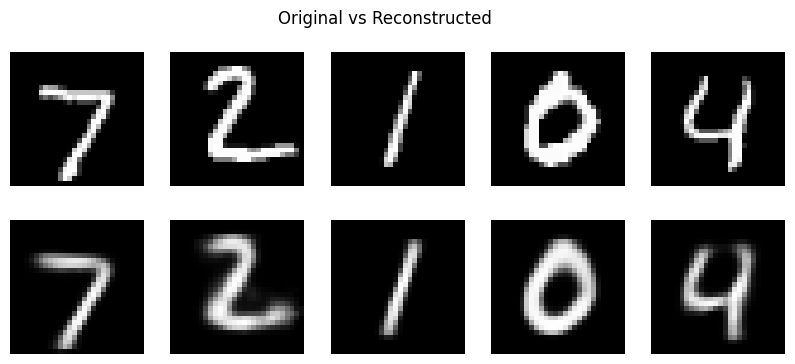

In [11]:
decoded_imgs = autoencoder.predict(XTest)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(XTest[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Original vs Reconstructed")
plt.show()

###  Latent Space (t-SNE)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


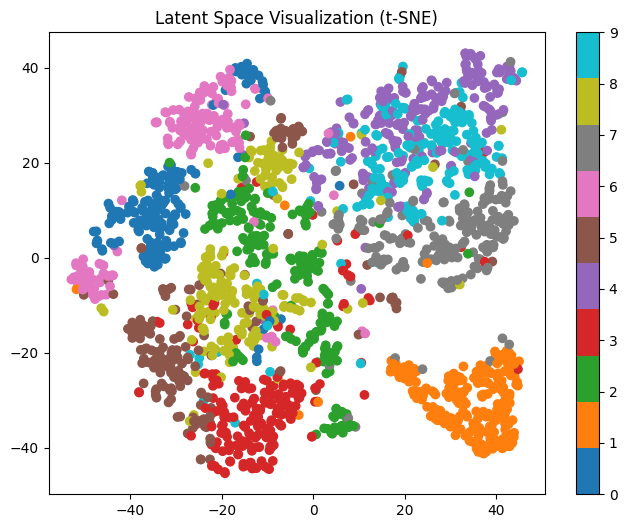

In [12]:
encoded_test = encoder.predict(XTest)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
encoded_2d = tsne.fit_transform(encoded_test[:2000])

plt.figure(figsize=(8,6))
plt.scatter(encoded_2d[:,0], encoded_2d[:,1], c=YTest[:2000], cmap='tab10')
plt.colorbar()
plt.title("Latent Space Visualization (t-SNE)")
plt.show()


### Image Retrieval

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step


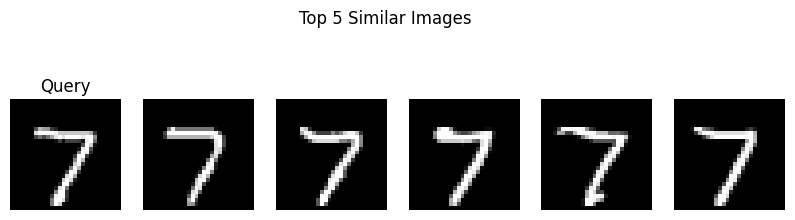

In [13]:
encoded_train = encoder.predict(XTrain)

def retrieve_similar(image_index=0):
    query = XTest[image_index].reshape(1, -1)
    query_encoded = encoder.predict(query)

    similarities = cosine_similarity(query_encoded, encoded_train)
    top5 = np.argsort(similarities[0])[-5:]

    plt.figure(figsize=(10,3))


    plt.subplot(1,6,1)
    plt.imshow(XTest[image_index].reshape(28,28), cmap='gray')
    plt.title("Query")
    plt.axis('off')

    for i, idx in enumerate(top5):
        plt.subplot(1,6,i+2)
        plt.imshow(XTrain[idx].reshape(28,28), cmap='gray')
        plt.axis('off')

    plt.suptitle("Top 5 Similar Images")
    plt.show()


retrieve_similar(0)


### Save Models

In [15]:
autoencoder.save("autoencoder.h5")
encoder.save("encoder.h5")

In [16]:
from google.colab import files

files.download('autoencoder.h5')
files.download('encoder.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>